In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install roboflow

from roboflow import Roboflow

In [ ]:


rf = Roboflow(api_key="D1XSKnC9265hy9sW4f3K")
project = rf.workspace("prince-sattam-bin-abdulaziz-university-njcb4").project("weapon-detection-bpm40")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:


rf = Roboflow(api_key="D1XSKnC9265hy9sW4f3K")
project = rf.workspace("sri-lanka-technological-campus-zil6s").project("knife-detection-ld5cb")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="D1XSKnC9265hy9sW4f3K")
project = rf.workspace("atharvadarke").project("real-world-gun-data")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="D1XSKnC9265hy9sW4f3K")
project = rf.workspace("train-yolov8-on-custom-dataset").project("knife-detection-azq4h")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'Knife-Detection-1', 'runs', 'real-world-gun-data-2', 'merged_dataset', 'yolov8n.pt', 'yolo26n.pt', 'weapon-detection--4', 'drive', 'Knife-detection-1', 'sample_data']


In [ ]:
import yaml

for folder in ["weapon-detection--4", "Knife-Detection-1"]:
    with open(f"/content/{folder}/data.yaml", "r") as f:
        data = yaml.safe_load(f)
    print(f"\n{folder}:")
    print(f"  classes: {data['names']}")
    print(f"  nc: {data['nc']}")


weapon-detection--4:
  classes: ['Guns', 'Rifle']
  nc: 2

Knife-Detection-1:
  classes: ['knife']
  nc: 1


In [ ]:

import os
import random
import shutil
from pathlib import Path
from collections import defaultdict


In [ ]:
random.seed(42)

In [ ]:
SOURCES = {
    "weapon-detection--4":     {"class_map": {0: 0, 1: 1}, "priority": False},
    "Knife-Detection-1":       {"class_map": {0: 2}, "priority": False},   # original (capital D)
    "real-world-gun-data-2":   {"class_map": {0: 0}, "priority": False},
    "Knife-detection-1":       {"class_map": {0: 2}, "priority": True},    # new realistic (lowercase d)
}

In [ ]:

CLASS_NAMES = ["Guns", "Rifle", "knife"]

TARGET_PER_CLASS = {
    "Guns": 50,
    "Rifle": 80,   # i bump this up since it's underperforming
    "knife": 50,
}
OUTPUT_DIR = Path("/content/merged_dataset")
SPLITS = ["train", "valid", "test"]

The function below will:
 - Walks train/valid/test subfolders of a roboflow yolov8 export.
 - Returns list of (image_path, label_path, set_of_classes_present) with labels remapped in-memory (not yet written).

In [ ]:
def collect_pairs(source_root, class_map):
  pairs = []
  source_root = Path(source_root)
  for split in SPLITS:
        img_dir = source_root / split / "images"
        lbl_dir = source_root / split / "labels"
        if not img_dir.exists():
            continue
        for img_path in img_dir.glob("*"):
            if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            if not lbl_path.exists():
                continue
            # read + remap labels
            remapped_lines = []
            classes_present = set()
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    old_cls = int(parts[0])
                    if old_cls not in class_map:
                        continue  # this is to skip the classes we don't care about
                    new_cls = class_map[old_cls]
                    classes_present.add(new_cls)
                    remapped_lines.append(" ".join([str(new_cls)] + parts[1:]))
            if remapped_lines:
                pairs.append((img_path, remapped_lines, classes_present))
  return pairs

all_pairs = []
for folder, cfg in SOURCES.items():
    src_path = f"/content/{folder}"
    found = collect_pairs(src_path, cfg["class_map"])
    found = [(img, lines, classes, cfg["priority"]) for (img, lines, classes) in found]
    print(f"{folder}: found {len(found)} labeled images")
    all_pairs.extend(found)

weapon-detection--4: found 2454 labeled images
Knife-Detection-1: found 723 labeled images
real-world-gun-data-2: found 979 labeled images
Knife-detection-1: found 1030 labeled images


Here is what the code below does:

- Group images by which weapon class(es) they contain.
- An image can have more than one class in it (e.g. a gun AND a knife),
- so instead of forcing each image into just one bucket, we add it to
- EVERY class bucket it belongs to. This lets us later pick a balanced
- number of images per class (e.g. ~50 Guns, ~50 Rifle, ~50 knife)
- instead of ending up with way more of one class than another.

In [ ]:
class_buckets = defaultdict(list)
for img_path, lines, classes_present, is_priority in all_pairs:
    for c in classes_present:
        class_buckets[c].append((img_path, lines, classes_present, is_priority))

# Shuffle first (for randomness within each tier), then sort
# priority=True images come first, this makes the more "realistic"
# knife dataset get picked before the cleaner one, within our TARGET_PER_CLASS cap.
for c in range(len(CLASS_NAMES)):
    random.shuffle(class_buckets[c])
    class_buckets[c].sort(key=lambda x: not x[3])  # False sorts after True

In [ ]:
print(CLASS_NAMES)

['Guns', 'Rifle', 'knife']


In [ ]:
for c in range(len(CLASS_NAMES)):
    random.shuffle(class_buckets[c])

selected = {}  # img_path, lines (dedup across classes since one image can satisfy multiple)
class_counts = defaultdict(int)

for c in range(len(CLASS_NAMES)):
    class_name = CLASS_NAMES[c]
    target = TARGET_PER_CLASS[class_name]   # look up this class's specific target
    for img_path, lines, classes_present, is_priority in class_buckets[c]:
        if class_counts[c] >= target:
            break
        if img_path in selected:
            for cc in classes_present:
                class_counts[cc] += 0
            continue
        selected[img_path] = lines
        for cc in classes_present:
            class_counts[cc] += 1

print("\nSelected image counts per class (images containing that class):")
for c, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_counts[c]}")
print(f"Total unique images selected: {len(selected)}")


Selected image counts per class (images containing that class):
  Guns: 54
  Rifle: 80
  knife: 50
Total unique images selected: 180


The code below is used to split the folders into train/valid/test

In [ ]:
items = list(selected.items())
random.shuffle(items)
n = len(items)
n_train = int(n * 0.7)   # training is 70%
n_valid = int(n * 0.2)   # validation is 20%
# remaining ~10% goes to test automatically
split_assignment = (
    [("train", x) for x in items[:n_train]] +
    [("valid", x) for x in items[n_train:n_train + n_valid]] +
    [("test", x) for x in items[n_train + n_valid:]]
)

The code below is to write out the final merged dataset to disk.
- For each selected image, copy the image file into the correct split
- folder (train/valid/test) and write its remapped labels into a
- matching .txt file. This creates one clean, unified dataset combining
- Guns + Rifle (from weapon-detection--4) and knife (from knife-Detection-1),
- with consistent class IDs (0=Guns, 1=Rifle, 2=knife) and a balanced
- train/valid/test split ready for YOLOv8 training.

In [ ]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for split in SPLITS:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

for split, (img_path, lines) in split_assignment:
    dest_img = OUTPUT_DIR / split / "images" / img_path.name
    dest_lbl = OUTPUT_DIR / split / "labels" / (img_path.stem + ".txt")
    shutil.copy(img_path, dest_img)
    with open(dest_lbl, "w") as f:
        f.write("\n".join(lines) + "\n")

This is the data.yaml config file that YOLOv8 needs to locate the train/valid/test folders and know the class names/order.

In [ ]:
yaml_content = f"""train: {OUTPUT_DIR}/train/images
val: {OUTPUT_DIR}/valid/images
test: {OUTPUT_DIR}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
with open(OUTPUT_DIR / "data.yaml", "w") as f:
    f.write(yaml_content)

print(f"\nMerged dataset written to: {OUTPUT_DIR}")
print(f"train: {n_train} | valid: {n_valid} | test: {n - n_train - n_valid}")
print("\nNext: drop your manually-collected diversity images into")
print(f"  {OUTPUT_DIR}/train/images and {OUTPUT_DIR}/train/labels")
print("(or re-run splitting after adding them) before training YOLOv8.")


Merged dataset written to: /content/merged_dataset
train: 125 | valid: 36 | test: 19

Next: drop your manually-collected diversity images into
  /content/merged_dataset/train/images and /content/merged_dataset/train/labels
(or re-run splitting after adding them) before training YOLOv8.


In [ ]:
import shutil
shutil.make_archive("/content/drive/MyDrive/merged_dataset_backup", 'zip', "/content/merged_dataset")

'/content/drive/MyDrive/merged_dataset_backup.zip'

In [ ]:
# Install ultralytics (YOLOv8)
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO("yolov8n.pt") #used nano cause of the small dataset

In [ ]:
# Train on merged dataset
results = model.train(
    data="/content/merged_dataset/data.yaml",
    epochs=100,          # small dataset, so i use 100 epochs.
    batch=16,
    patience=20,         # stops early if val performance plateaus for 20 epochs
    project="/content/runs",
    name="weapon_detector",
    exist_ok=True,
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [ ]:
import shutil

# this is to copy best.pt to a clean, easy-to-find location
shutil.copy(
    "/content/runs/weapon_detector/weights/best.pt",
    "/content/best_weapon_model.pt"
)
print("Copied to /content/best_weapon_model.pt")

Copied to /content/best_weapon_model.pt


In [ ]:
from google.colab import files
files.download("/content/best_weapon_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.copy(
    "/content/best_weapon_model.pt",
    "/content/drive/MyDrive/best_weapon_model.pt"
)
print("Backed up to Google Drive")

Backed up to Google Drive


In [ ]:
from google.colab import files
files.download("/content/runs/weapon_detector/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/runs/weapon_detector/results.png")       # training curves (loss, mAP over epochs)
files.download("/content/runs/weapon_detector/val_batch0_pred.jpg")  # sample predictions on val set

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
import glob

model = YOLO("/content/best_weapon_model.pt")

# Run inference on held-out test images
test_images = glob.glob("/content/merged_dataset/test/images/*")
results = model.predict(
    source=test_images,
    save=True,
    conf=0.25,          # confidence threshold, to adjust if too many/few detections show
    project="/content/runs",
    name="test_predictions",
    exist_ok=True,
)

print(f"Ran inference on {len(test_images)} test images")
print("Results saved to /content/runs/test_predictions/")


0: 640x640 2 Gunss, 4.7ms
1: 640x640 (no detections), 4.7ms
2: 640x640 (no detections), 4.7ms
3: 640x640 1 knife, 4.7ms
4: 640x640 (no detections), 4.7ms
5: 640x640 1 Guns, 4.7ms
6: 640x640 (no detections), 4.7ms
7: 640x640 (no detections), 4.7ms
8: 640x640 (no detections), 4.7ms
9: 640x640 (no detections), 4.7ms
10: 640x640 1 knife, 4.7ms
11: 640x640 1 Guns, 4.7ms
12: 640x640 1 knife, 4.7ms
13: 640x640 1 Rifle, 4.7ms
14: 640x640 (no detections), 4.7ms
15: 640x640 (no detections), 4.7ms
16: 640x640 11 Rifles, 4.7ms
17: 640x640 3 Rifles, 4.7ms
18: 640x640 1 Guns, 4.7ms
Speed: 2.8ms preprocess, 4.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/test_predictions
Ran inference on 19 test images
Results saved to /content/runs/test_predictions/


In [ ]:
import os

pred_files = os.listdir("/content/runs/test_predictions/")
print(pred_files)  # to see what's available, then download a few

['image18.jpg', 'image3.jpg', 'image0.jpg', 'image17.jpg', 'image16.jpg', 'image14.jpg', 'image1.jpg', 'image2.jpg', 'image7.jpg', 'image13.jpg', 'image15.jpg', 'image5.jpg', 'image4.jpg', 'image10.jpg', 'image6.jpg', 'image12.jpg', 'image8.jpg', 'image11.jpg', 'image9.jpg']


In [ ]:
import os
pred_files = sorted(os.listdir("/content/runs/test_predictions/"))
print(pred_files)

['image0.jpg', 'image1.jpg', 'image10.jpg', 'image11.jpg', 'image12.jpg', 'image13.jpg', 'image14.jpg', 'image15.jpg', 'image16.jpg', 'image17.jpg', 'image18.jpg', 'image2.jpg', 'image3.jpg', 'image4.jpg', 'image5.jpg', 'image6.jpg', 'image7.jpg', 'image8.jpg', 'image9.jpg']


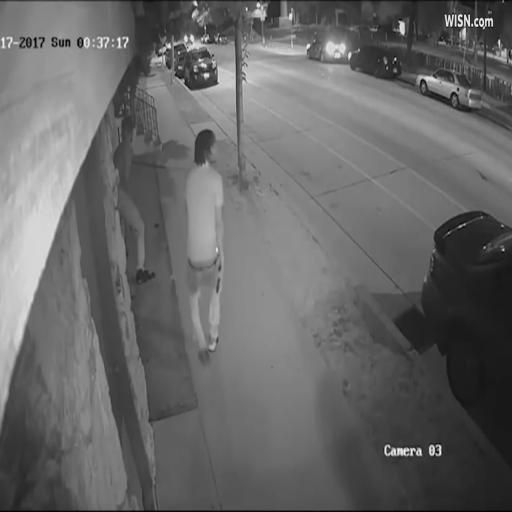

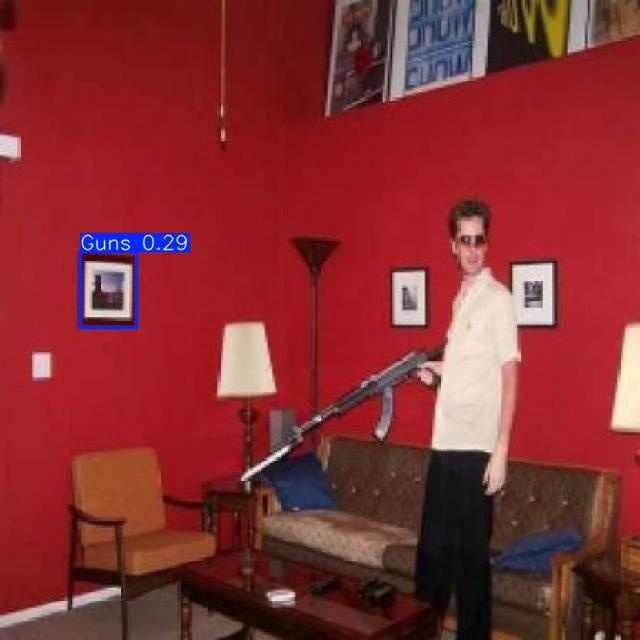

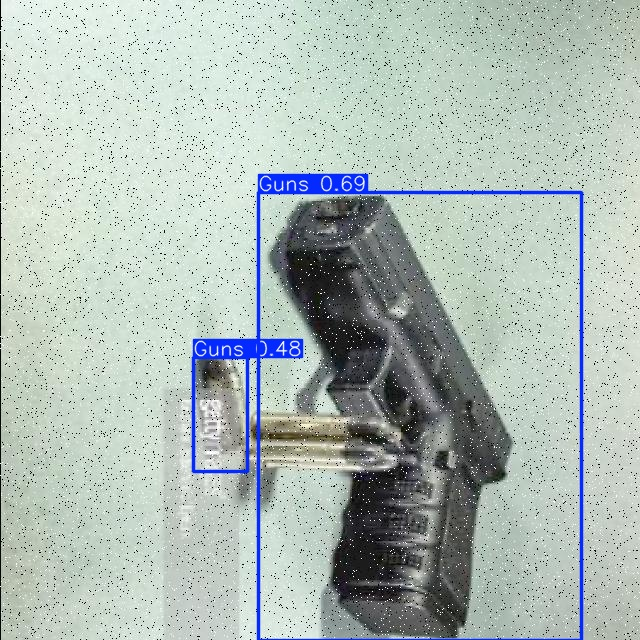

In [ ]:
from IPython.display import Image, display

# View a few interesting ones - adjust filenames based on what pred_files showed
display(Image("/content/runs/test_predictions/" + pred_files[16]))  # the "11 Rifles"
display(Image("/content/runs/test_predictions/" + pred_files[3]))   # a knife detection
display(Image("/content/runs/test_predictions/" + pred_files[0]))   # a Guns detection